# **xT model evaluation**
---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1XEzNdi2b6REpVnaUC4E0Cz_TQQUJarjR)

In the previouse notebook [*Calculation of the xT model*](https://github.com/MSI17819/Football_projects/blob/main/Code/xT_model_calculation.ipynb) I save the *xT matrix*, as a csv file and then use this matrix here to evaluate the players performance. In this notebook, I evaluate the *xT* model on:

* *Women Uefa Euro 2022*
* *FA Women's Super League 2020/2021*

Events data provided by [Hudl StatsBomb](https://github.com/statsbomb/open-data)

---

### **1) Import needed packages and libraries**

In [54]:
# Football package instalation for Colab virtual enviroment
%pip install mplsoccer -q
%pip install statsbombpy -q
%pip install plottable -q

In [ ]:
# Import needed packages
import numpy as np
import pandas as pd
pd.options.mode.copy_on_write = True
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Import football packages
from statsbombpy import sb
from mplsoccer import Pitch
from mplsoccer import VerticalPitch
from mplsoccer import FontManager
from mplsoccer import Sbopen

# Plottable library
from plottable import Table
from plottable import ColumnDefinition
from plottable.cmap import normed_cmap

# Import font type OpenSans
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('/content/drive/MyDrive/OpenSans-Italic-VariableFont_wdth,wght[1].ttf')
plt.rcParams["font.family"] = "Open Sans"
warnings.filterwarnings("ignore")

### **2) xT model evaluation combine with players minutes for Women Euro 2022**

For the first 50 names of players with the best *xT score* from data, I added information about minutes played and player country. The information is stored in a csv file *xT_first_50_women_Euro_2022* (minutes obtained from the [FBref](https://fbref.com/en/comps/162/stats/UEFA-Womens-Euro-Stats) website). This data allowed to calculate the *xT per 90* metrics to normalize the performance of each players. I displayed a new players classification list with the best *xT per 90* metric.

In [55]:
url = 'https://raw.githubusercontent.com/MSI17819/Football_projects/refs/heads/main/Data/xT_transition_matrix_women_base_on_wsl_two_seasons_2018_and_2020.csv'

# Load each xT_matrix from csv file
xT = pd.read_csv(url, header=None)

In [56]:
def load_data_func(xT) :

    """Return the shape of each xT matrix.

    Args:
      xT (df): data in df format.

    Returns:
      np.array: xT matrix.

    """
    # Convert df with matrix to numpy array
    xT = np.array(xT)

    return xT

In [57]:
xT = load_data_func(xT)

In [58]:
def data_modf(competition_id, season_id, xT):

  """Return pass event for all matches.

  Args:
    competition id: data in int format from Hudl Statsbombs API.
    season id: data in int format from Hudl StatsBombs API.
    xT: data in np.array format

  Returns:
    df: df with xT value for each record.

  """
  # Instantiate a parser object from mplsoccer package
  parser = Sbopen()

  # Parse StatsBomb data match with parser object above
  df_match = parser.match(competition_id, season_id)
  match_ids = df_match.match_id.unique()

  # Create a df with all needed columns and event (I consider only passes) for our xT model evaluation
  all_pass_df = []
  cols = ['match_id', 'id', 'player_id','type_name', 'sub_type_name', 'player_name',
          'x', 'y', 'end_x', 'end_y', 'position_id', 'position_name','outcome_name'
          ]

  for match_id in match_ids:
      # Get passes events
      event = parser.event(match_id)[0]  # get the first dataframe (events) which has index = 0
      event = event.loc[event.type_name.isin(['Pass']), cols].copy()
      all_pass_df.append(event)

  all_pass = pd.concat(all_pass_df)

  # Clean df only witch needed values
  val_list = ['Incomplete', 'Out', 'Pass Offside', 'Unknown',
              'Injury Clearance', 'Kick Off','Recovery', 'Goal Kick',
              'Throw-in', 'Free Kick', 'Interception'
              ]

  xT_model = all_pass[~all_pass[["outcome_name", "sub_type_name"]].isin(val_list).any(axis=1)]
  # Reset index
  xT_model.reset_index(drop=True, inplace=True)

  # xT rows columns from shape
  xT_rows, xT_col = xT.shape

  # Cut bins for women df
  xT_model['x_bin'] = pd.cut(xT_model['x'], bins=xT_col, labels=False)
  xT_model['y_bin'] = pd.cut(xT_model['y'], bins=xT_rows, labels=False)
  xT_model['x_bin_end'] = pd.cut(xT_model['end_x'], bins=xT_col, labels=False)
  xT_model['y_bin_end'] = pd.cut(xT_model['end_y'], bins=xT_rows, labels=False)

  # Lay a xT and xT_men matrix into women
  xT_model['start_sector'] = xT_model[['x_bin', 'y_bin']].apply(lambda x: xT[x[1]][x[0]], axis=1)
  xT_model['end_sector'] = xT_model[['x_bin_end', 'y_bin_end']].apply(lambda x: xT[x[1]][x[0]], axis=1)

  # xT calulaction for women
  xT_model['xT_val'] = xT_model['end_sector'] - xT_model['start_sector']

  return xT_model

In [59]:
# Load Hudl StatsBomb data UEFA Women Euro 2022 competition
xT_women_model = data_modf(53, 106, xT)

In [62]:
# Loading a csv file with the values of minutes played by the first 50 players grouped by name (FBref data)
player_min = pd.read_csv('/content/drive/MyDrive/Project_finished_code_for_Git/xT_first_50_women_Euro_2022.csv', sep=';', encoding='latin-1')

In [ ]:
def xT_val_per_90(xT_model, min_played):

  """Return df with value of xT per 90 min normalization.

  Args:
    xT_model: data in df format.
    min_played: data in df format.

  Returns:
    df: df with xT per 90 min column.

  """
  # Merge minute played with players names
  xT_per_90_model = xT_model.merge(min_played, on='player_name', how='inner')

  # Calculation of the new xT_per_90 metrics
  xT_per_90_model["xT_per_90"] = (xT_per_90_model['xT_val'])*90/xT_per_90_model['min_played']

  return xT_per_90_model

In [ ]:
xT_women_model = xT_val_per_90(xT_women_model, player_min)

In [ ]:
# Players with highest xT_per_90 minutes value
xT_women_model.groupby(['player_name', 'position_name', 'country', 'min_played'])['xT_per_90'].sum().sort_values(ascending=False).head(50)

,,,,xT_per_90
player_name,position_name,country,min_played,
María Pilar León Cebrián,Left Center Back,Spain,390,0.480158
Marie-Antoinette Katoto,Center Forward,France,92,0.471799
María Francesca Caldentey Oliver,Left Wing,Spain,362,0.364450
Sakina Karchaoui,Left Back,France,414,0.311672
Sara Gama,Right Center Back,Italy,147,0.306602
Irene Paredes Hernandez,Right Center Back,Spain,390,0.293435
Svenja Huth,Right Wing,German,541,0.284363
Lisa Boattin,Left Back,Italy,270,0.263191
Clara Mateo,Left Center Midfield,France,218,0.245998


In [ ]:
# Players with highest xT_per_90 minutes value in final 3rd pitch area flatten
xT_women_model_grouped = xT_women_model.groupby(['player_name', 'position_name', 'country', 'min_played'], as_index=False)['xT_per_90'].sum().sort_values(by='xT_per_90', ascending=False).head(50)

In [ ]:
# Index setting for table vizualisation
xT_women_model_grouped.set_index('player_name', inplace=True)

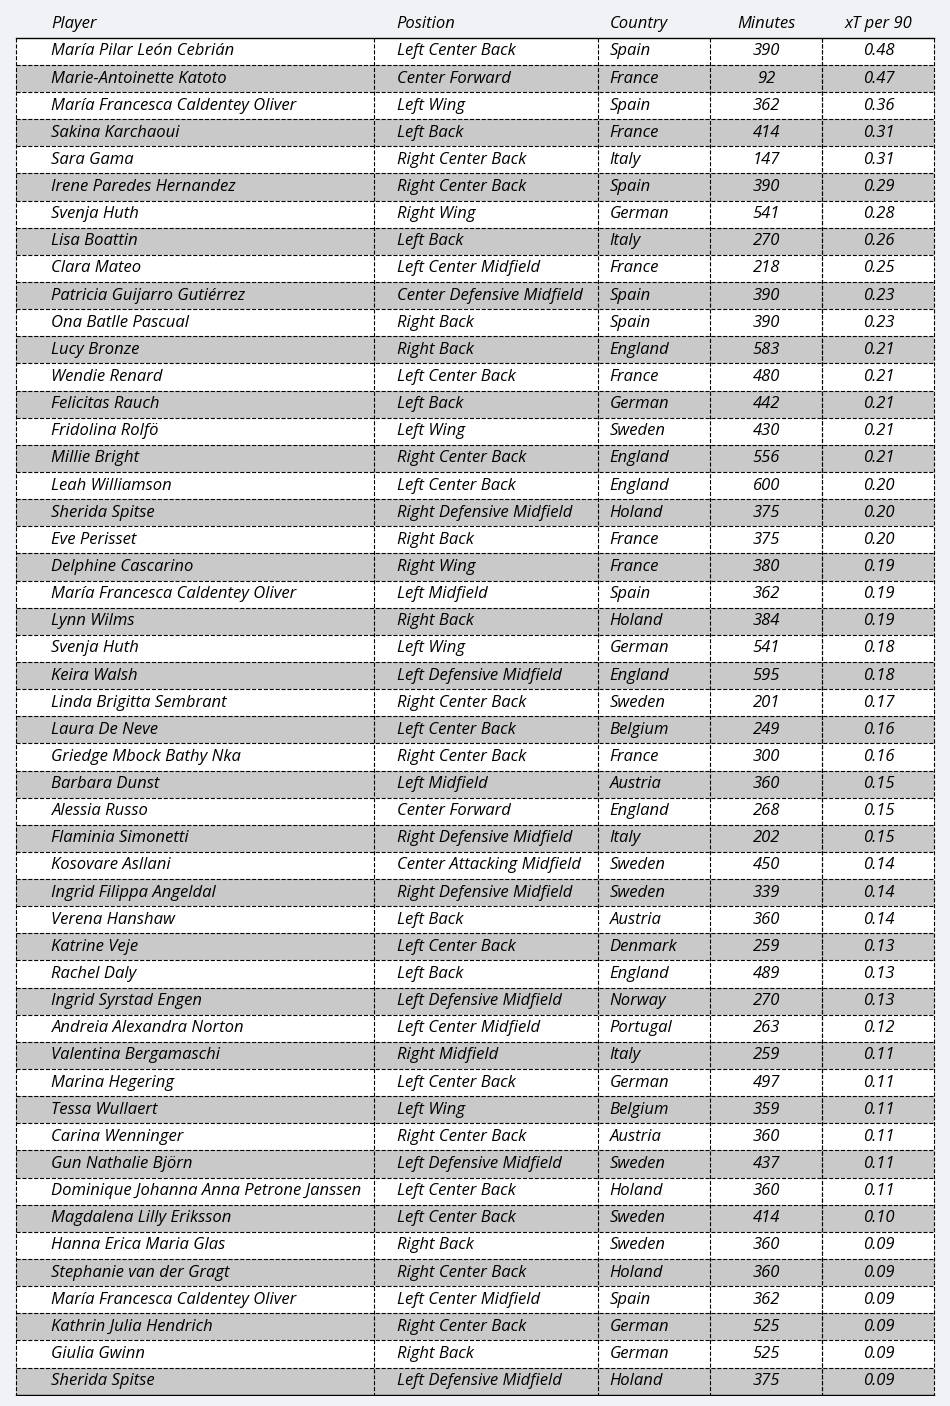

In [ ]:
# Color for table rows
row_colors = {
    "even": "#ffffff",
    "odd": "#c9c9c9",
    "bg_color": "#f0f2f5"
    }

# Facecolor
bg_color = row_colors["bg_color"]

col_defs = [
    ColumnDefinition(name="player_name", title='Player', textprops={"ha": "left"}, width=1.6, border='left'),
    ColumnDefinition(name="position_name", title="Position",textprops={"ha": "left"}, width=1., border='both'),
    ColumnDefinition(name="country", title='Country',textprops={"ha": "left"}, width=0.5, border='right'),
    ColumnDefinition(name="min_played", title='Minutes',textprops={"ha": "center"}, width=0.5, border='right'),
    ColumnDefinition(name="xT_per_90", title='xT per 90', textprops={"ha": "center"}, formatter='{:.2f}', width=0.5, border='both')
    ]

fig, ax = plt.subplots(figsize=(12, 18))

fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

tab = Table(xT_women_model_grouped,
            column_definitions=col_defs,
            row_dividers=True,
            footer_divider=True,
            ax=ax,
            odd_row_color=row_colors["odd"],
            even_row_color=row_colors["even"],
            row_divider_kw={"linewidth": 0.8, "linestyle": "--"},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 0.8, "linestyle": "--"},
            textprops={"fontsize": 12, "ha": "center", "fontname": "Open Sans"}
            )

plt.show()

#### **xT model evaluation only for final 3rd pitch area**

Finally, the data was filtered only for players with the highest xT in the final 3rd area:
- final 3rd area = 40 meter ahead of goal
- passes end in final 3rd area

In [ ]:
# Filtering data only in passes end in final 3rd area
final_third_mask = (xT_women_model['end_x'] >= 80)
xT_women_model_final_third = xT_women_model[final_third_mask]

In [ ]:
# Players with highest xT in final 3rd area
xT_women_model_final_third.groupby(['player_name', 'position_name', 'country', 'min_played'], as_index=False)['xT_val'].sum().sort_values(by='xT_val', ascending=False).head(50)

,player_name,position_name,country,min_played,xT_val
80,Svenja Huth,Right Wing,German,541,1.902675
63,María Francesca Caldentey Oliver,Left Wing,Spain,362,1.604591
65,María Pilar León Cebrián,Left Center Back,Spain,390,1.501840
54,Lucy Bronze,Right Back,England,583,1.469652
74,Sakina Karchaoui,Left Back,France,414,1.452987
69,Patricia Guijarro Gutiérrez,Center Defensive Midfield,Spain,390,1.421585
44,Keira Walsh,Left Defensive Midfield,England,595,1.391200
20,Felicitas Rauch,Left Back,German,442,1.103146
25,Fridolina Rolfö,Left Wing,Sweden,430,1.102201
79,Svenja Huth,Left Wing,German,541,1.084729


In [ ]:
# Players with highest xT_per_90 minutes value in final 3rd pitch area
xT_women_model_final_third.groupby(['player_name', 'position_name', 'country', 'min_played'], as_index=False)['xT_per_90'].sum().sort_values(by='xT_per_90', ascending=False).head(50)

,player_name,position_name,country,min_played,xT_per_90
58,Marie-Antoinette Katoto,Center Forward,France,92,0.492513
63,María Francesca Caldentey Oliver,Left Wing,Spain,362,0.398931
65,María Pilar León Cebrián,Left Center Back,Spain,390,0.346578
69,Patricia Guijarro Gutiérrez,Center Defensive Midfield,Spain,390,0.328058
80,Svenja Huth,Right Wing,German,541,0.316526
74,Sakina Karchaoui,Left Back,France,414,0.315867
75,Sara Gama,Right Center Back,Italy,147,0.267752
12,Clara Mateo,Left Center Midfield,France,218,0.259802
53,Lisa Boattin,Left Back,Italy,270,0.256702
62,María Francesca Caldentey Oliver,Left Midfield,Spain,362,0.241039


In [ ]:
# Players with highest xT_per_90 minutes value in final 3rd pitch area flatten
xT_women_model_final_third_per_90 = xT_women_model_final_third.groupby(['player_name', 'position_name', 'country', 'min_played'], as_index=False)['xT_per_90'].sum().sort_values(by='xT_per_90', ascending=False).head(50)

In [ ]:
# Set index for vizualisation matter
xT_women_model_final_third_per_90.set_index('player_name', inplace=True)

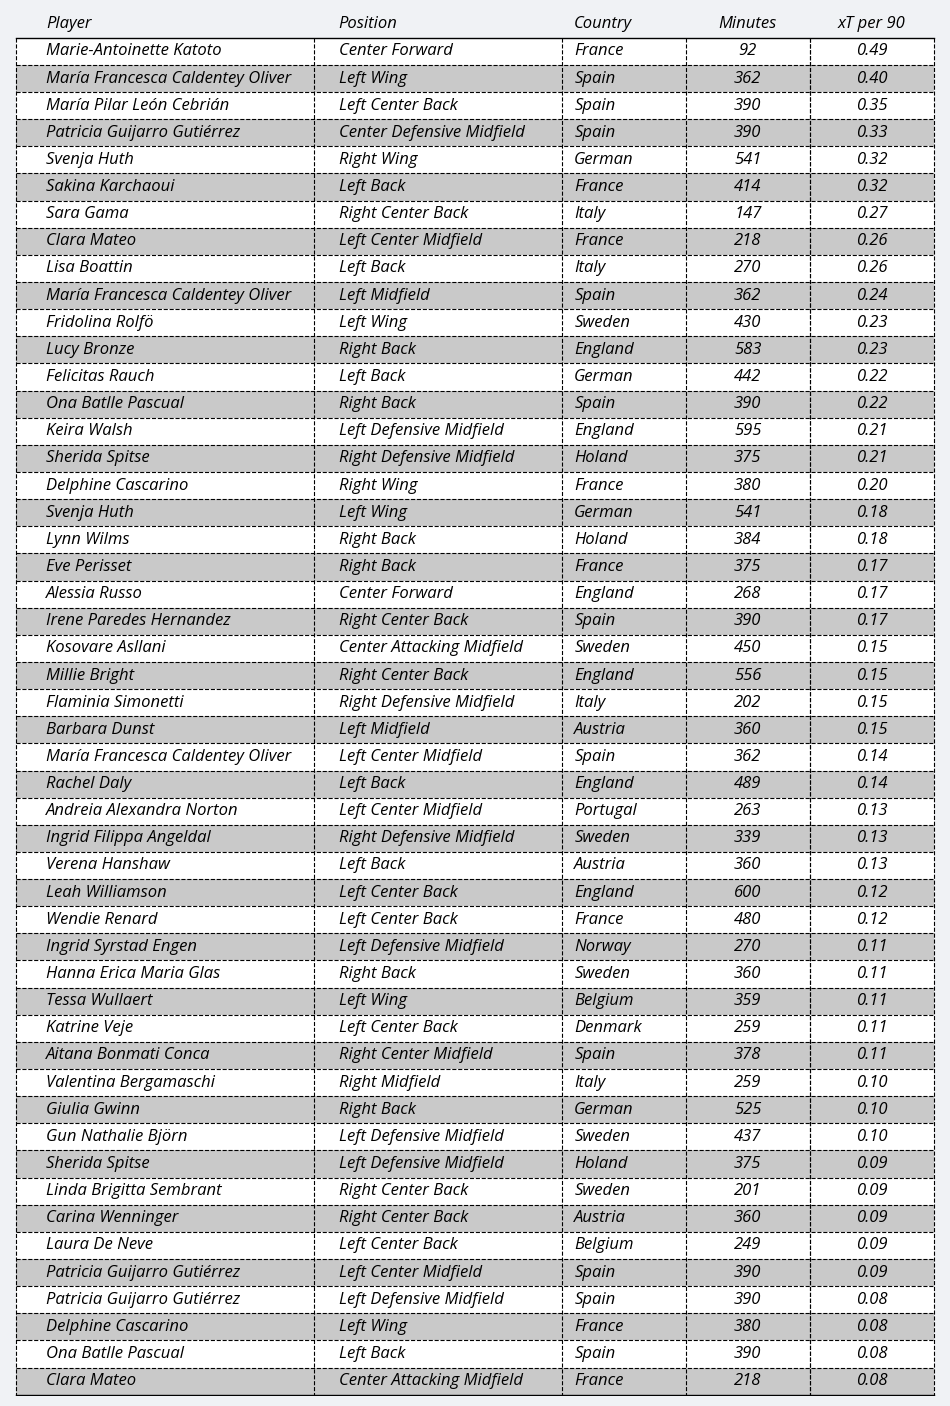

In [ ]:
# Color for table rows
row_colors = {
    "even": "#ffffff",
    "odd": "#c9c9c9",
    "bg_color": "#f0f2f5"
    }

# Facecolor
bg_color = row_colors["bg_color"]

col_defs = [
    ColumnDefinition(name="player_name", title='Player', textprops={"ha": "left"}, width=1.2, border='left'),
    ColumnDefinition(name="position_name", title="Position",textprops={"ha": "left"}, width=1., border='both'),
    ColumnDefinition(name="country", title='Country',textprops={"ha": "left"}, width=0.5, border='right'),
    ColumnDefinition(name="min_played", title='Minutes',textprops={"ha": "center"}, width=0.5, border='right'),
    ColumnDefinition(name="xT_per_90", title='xT per 90', textprops={"ha": "center"}, formatter='{:.2f}', width=0.5, border='both')
    ]

fig, ax = plt.subplots(figsize=(12, 18))

fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

tab = Table(xT_women_model_final_third_per_90,
            column_definitions=col_defs,
            row_dividers=True,
            footer_divider=True,
            ax=ax,
            odd_row_color=row_colors["odd"],
            even_row_color=row_colors["even"],
            row_divider_kw={"linewidth": 0.8, "linestyle": "--"},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 0.8, "linestyle": "--"},
            textprops={"fontsize": 12, "ha": "center", "fontname": "Open Sans"}
            )

plt.show()

### **3) xT model evaluation combine with players minutes for Women Super League 2020/2021**

For the first 50 names of players with the best *xT score*, I added information about minutes played, player nationality and current league club. The information is stored in a csv file *xT_first50_women_wsl_two_seasons_super_league* (minutes obtained from the [FBref](https://fbref.com/en/comps/162/stats/UEFA-Womens-Euro-Stats) website).
This data allowed to calculate the *xT per 90* metrics to normalize the performance of each players. I displayed a new players classification list with the best *xT per 90* metric.

In [ ]:
# Apply xT matrix to Hudl StatBombs data Women Super League season 2020/2021
xT_women_model_super_league = data_modf(37, 90, xT)

In [ ]:
# Group df by player name and sum of xT values for first best 50 players
xT_women_model_super_league.groupby(['player_name', 'position_name'])['xT_val'].sum().sort_values(ascending=False).head(50)

,,xT_val
player_name,position_name,
Leah Williamson,Right Center Back,6.370244
Magdalena Lilly Eriksson,Left Center Back,5.638883
Katie McCabe,Left Back,5.369334
Alex Greenwood,Left Center Back,4.816424
Lucy Bronze,Right Back,4.500848
Millie Bright,Right Center Back,4.472447
Stephanie Houghton,Right Center Back,4.150057
Jonna Ann-Charlotte Andersson,Left Back,3.002068
Keira Walsh,Center Defensive Midfield,2.979241


In [ ]:
# Group df by player name and sum of xT values for first 50 players
xT_women_model.groupby(['player_name', 'position_name'])['xT_val'].sum().sort_values(ascending=False).head(50)

,,xT_val
player_name,position_name,
María Pilar León Cebrián,Left Center Back,2.080684
Svenja Huth,Right Wing,1.709338
María Francesca Caldentey Oliver,Left Wing,1.465897
Sakina Karchaoui,Left Back,1.433693
Lucy Bronze,Right Back,1.376994
Leah Williamson,Left Center Back,1.366052
Irene Paredes Hernandez,Right Center Back,1.271550
Millie Bright,Right Center Back,1.269056
Keira Walsh,Left Defensive Midfield,1.182308


In [64]:
# Loading a csv file with the values of minutes played by the first 50 players grouped by name (FBref data)
player_min_league = pd.read_csv('/content/drive/MyDrive/Project_finished_code_for_Git/xT_first_50_women_minute_super_league.csv', sep=';', encoding='latin-1')

In [ ]:
xT_women_model_super_league = xT_val_per_90(xT_women_model_super_league, player_min_league)

In [ ]:
# Players with highest xT_per_90 minutes value
xT_women_model_super_league.groupby(['player_name', 'position_name', 'min_played', 'club', 'nationality'])['xT_per_90'].sum().sort_values(ascending=False).head(50)

,,,,,xT_per_90
player_name,position_name,min_played,club,nationality,
Alex Greenwood,Left Center Back,1556,Manchester City,England,0.557170
Leah Williamson,Right Center Back,1674,Arsenal,England,0.342486
Magdalena Lilly Eriksson,Left Center Back,1715,Chelsea,Sweden,0.295918
Katie McCabe,Left Back,1735,Arsenal,Irleand,0.278525
Lucy Bronze,Right Back,1525,Manchester City,England,0.265624
Stephanie Houghton,Right Center Back,1415,Manchester City,England,0.263961
Ona Batlle Pascual,Left Back,1632,Manchester United,Spain,0.228265
Alex Greenwood,Left Back,1556,Manchester City,England,0.226765
Abbie McManus,Right Center Back,900,Tottenham,England,0.225053


In [ ]:
# Players with highest xT_per_90 minutes value flatten
xT_women_model_super_league_grouped = xT_women_model_super_league.groupby(['player_name', 'position_name', 'min_played', 'club', 'nationality'], as_index=False)['xT_per_90'].sum().sort_values(by='xT_per_90', ascending=False).head(50)

In [ ]:
# Set index for vizualisation matter
xT_women_model_super_league_grouped.set_index('player_name', inplace=True)

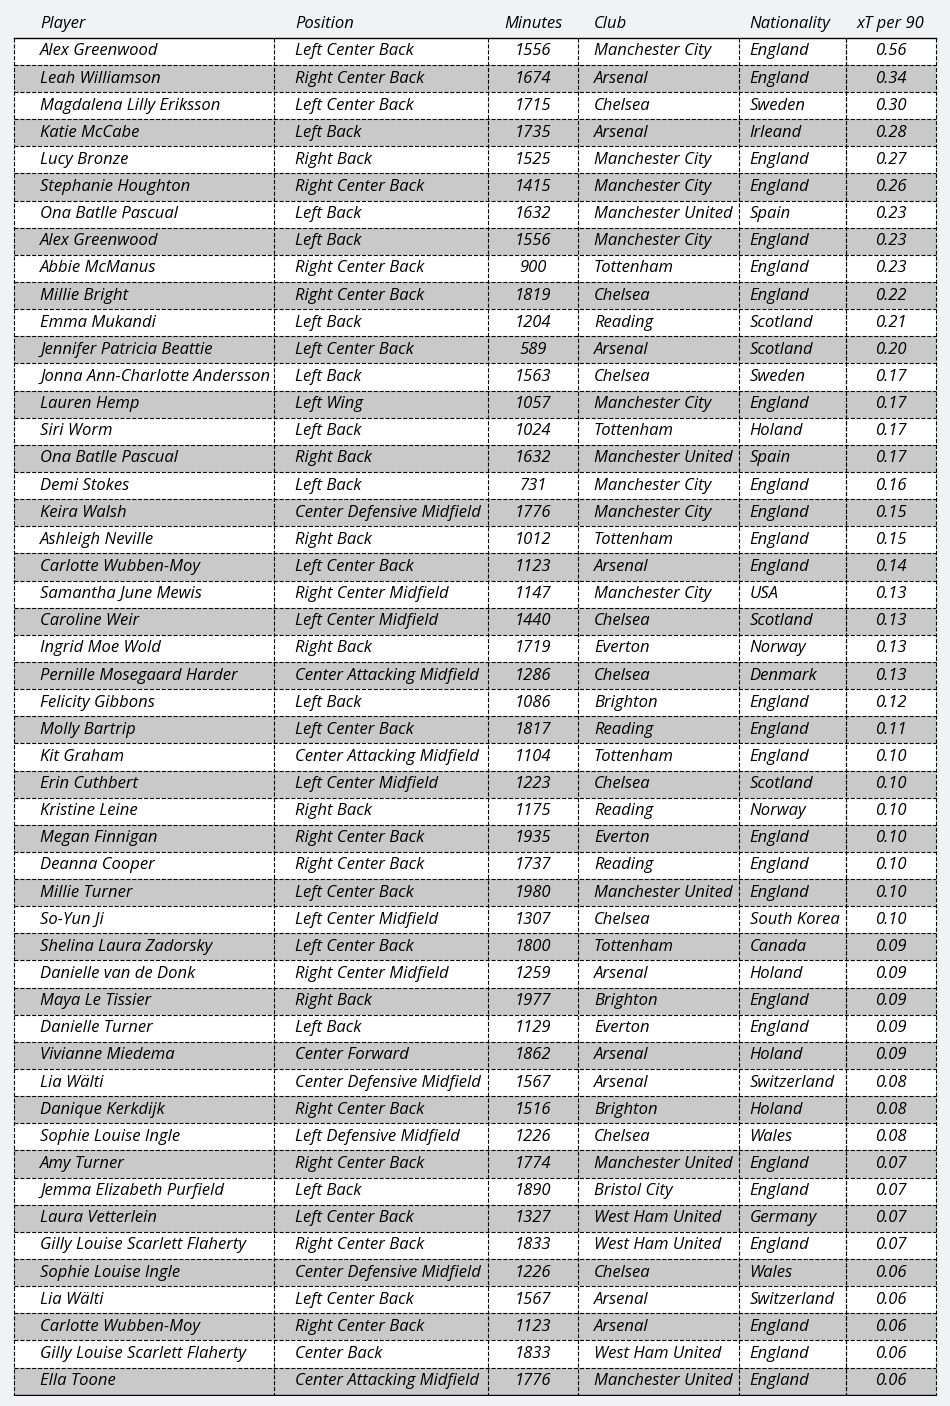

In [ ]:
# Color for table rows
row_colors = {
    "even": "#ffffff",
    "odd": "#c9c9c9",
    "bg_color": "#f0f2f5"
    }

# Facecolor
bg_color = row_colors["bg_color"]

col_defs = [
    ColumnDefinition(name="player_name", title='Player', textprops={"ha": "left"}, width=1.45, border='left'),
    ColumnDefinition(name="position_name", title="Position",textprops={"ha": "left"}, width=1.2, border='both'),
    ColumnDefinition(name="nationality", title='Nationality',textprops={"ha": "left"}, width=0.6, border='right'),
    ColumnDefinition(name="club", title='Club',textprops={"ha": "left"}, width=0.9, border='right'),
    ColumnDefinition(name="min_played", title='Minutes',textprops={"ha": "center"}, width=0.5, border='right'),
    ColumnDefinition(name="xT_per_90", title='xT per 90', textprops={"ha": "center"}, formatter='{:.2f}', width=0.5, border='both')
    ]

fig, ax = plt.subplots(figsize=(12, 18))

fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

tab = Table(xT_women_model_super_league_grouped,
            column_definitions=col_defs,
            row_dividers=True,
            footer_divider=True,
            ax=ax,
            odd_row_color=row_colors["odd"],
            even_row_color=row_colors["even"],
            row_divider_kw={"linewidth": 0.8, "linestyle": "--"},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 0.8, "linestyle": "--"},
            textprops={"fontsize": 12, "ha": "center", "fontname": "Open Sans"}
            )

plt.show()

#### **xT model evaluation only for final 3rd pitch area**

Finally, the data was filtered only for players with the highest xT in the final 3rd area:
- final 3rd area = 40 meter ahead of goal
- passes end in final 3rd area

In [ ]:
# Filtering data only in final 3rd area
final_third_mask = (xT_women_model_super_league['end_x'] >= 80)
xT_women_model_super_league_final_third = xT_women_model_super_league[final_third_mask]

In [ ]:
# Players with highest xT_per_90 minutes value in final 3rd pitch area flatten
xT_women_model_super_league_final_third_per_90 = xT_women_model_super_league_final_third.groupby(['player_name', 'position_name', 'club', 'nationality', 'min_played'], as_index=False)['xT_per_90'].sum().sort_values(by='xT_per_90', ascending=False).head(50)

In [ ]:
# Set index for vizualisation matter
xT_women_model_super_league_final_third_per_90.set_index('player_name', inplace=True)

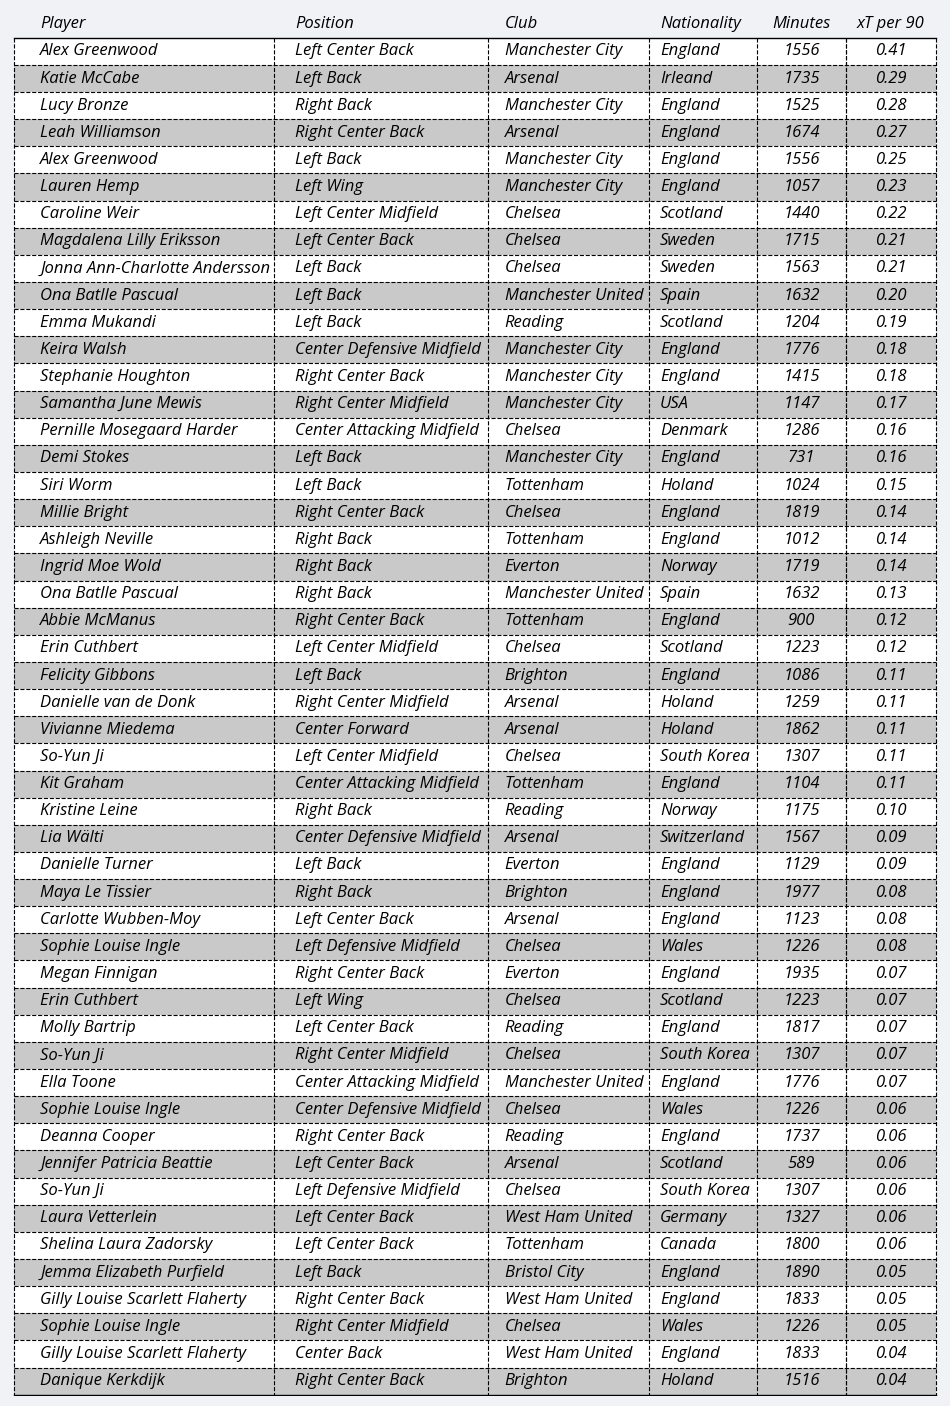

In [ ]:
# Color for table rows
row_colors = {
    "even": "#ffffff",
    "odd": "#c9c9c9",
    "bg_color": "#f0f2f5"
    }

# Facecolor
bg_color = row_colors["bg_color"]

col_defs = [
    ColumnDefinition(name="player_name", title='Player', textprops={"ha": "left"}, width=1.45, border='left'),
    ColumnDefinition(name="position_name", title="Position",textprops={"ha": "left"}, width=1.2, border='both'),
    ColumnDefinition(name="nationality", title='Nationality',textprops={"ha": "left"}, width=0.6, border='right'),
    ColumnDefinition(name="club", title='Club',textprops={"ha": "left"}, width=0.9, border='right'),
    ColumnDefinition(name="min_played", title='Minutes',textprops={"ha": "center"}, width=0.5, border='right'),
    ColumnDefinition(name="xT_per_90", title='xT per 90', textprops={"ha": "center"}, formatter='{:.2f}', width=0.5, border='both')
    ]

fig, ax = plt.subplots(figsize=(12, 18))

fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

tab = Table(xT_women_model_super_league_final_third_per_90,
            column_definitions=col_defs,
            row_dividers=True,
            footer_divider=True,
            ax=ax,
            odd_row_color=row_colors["odd"],
            even_row_color=row_colors["even"],
            row_divider_kw={"linewidth": 0.8, "linestyle": "--"},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 0.8, "linestyle": "--"},
            textprops={"fontsize": 12, "ha": "center", "fontname": "Open Sans"}
            )

plt.show()

### **4) Visualization passes of the top 3 players with the highest *xT per 90* in final 3rd pitch area from 2020/2021 season** ###

In [ ]:
top_first_player = xT_women_model_super_league_final_third.query('player_name == "Alex Greenwood" and position_name == "Left Center Back"')
top_secound_player = xT_women_model_super_league_final_third.query('player_name == "Katie McCabe" and position_name == "Left Back"')
top_third_player = xT_women_model_super_league_final_third.query('player_name == "Lucy Bronze" and position_name == "Right Back"')

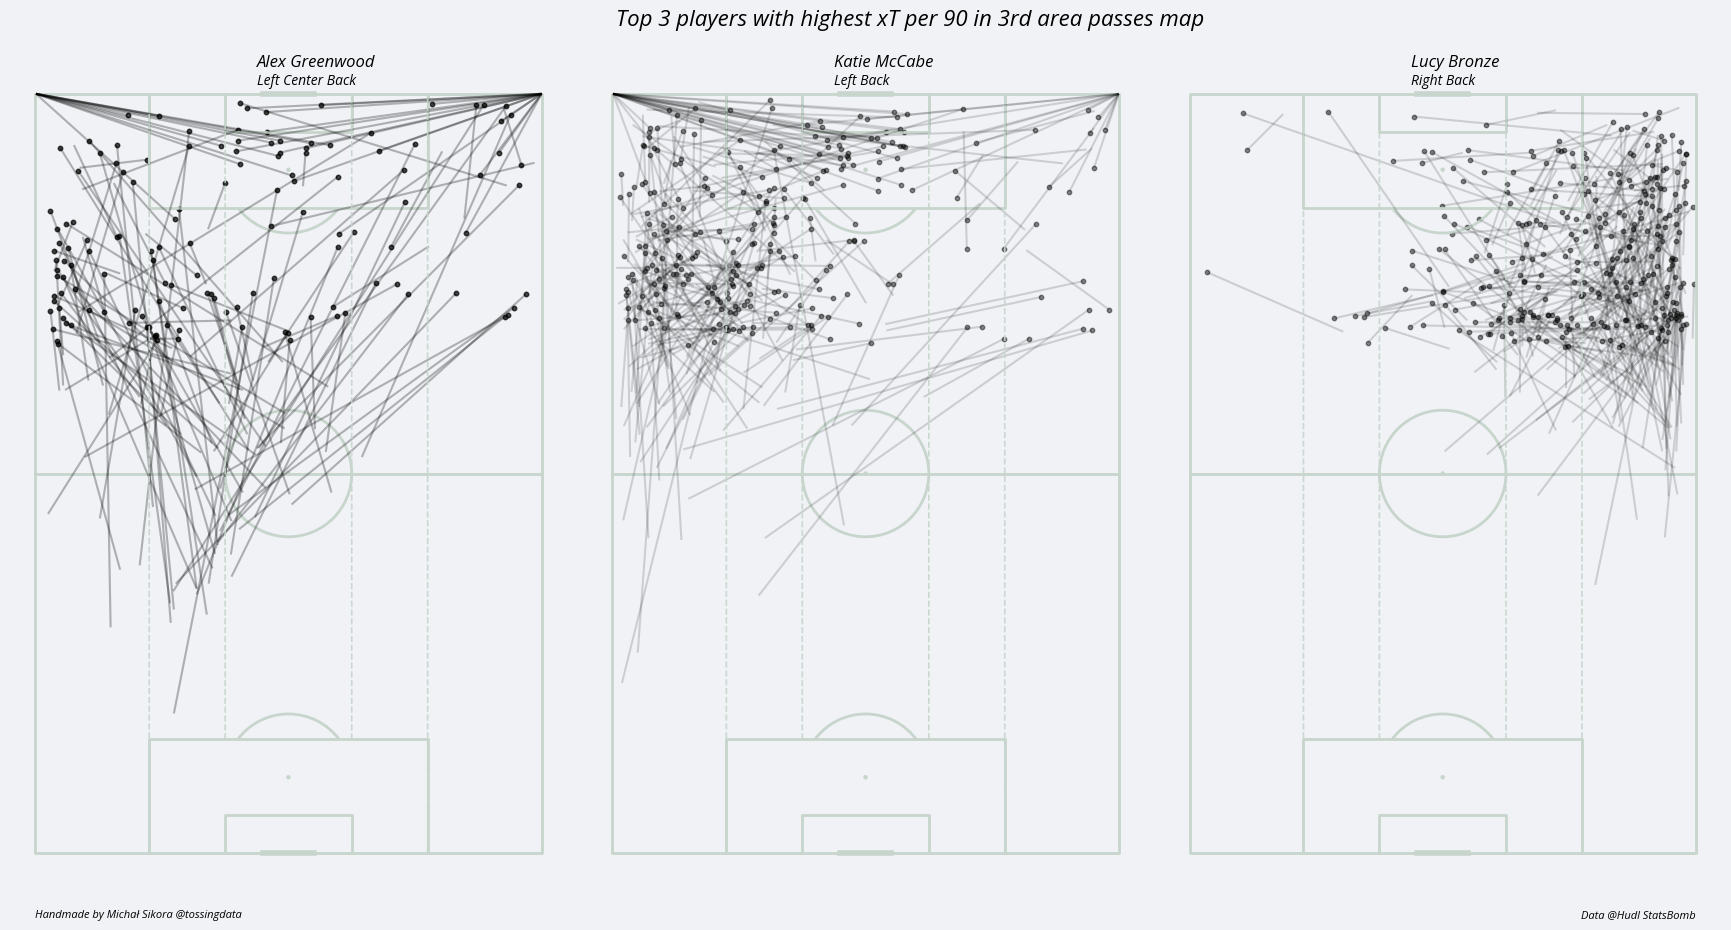

In [ ]:
top_3_players = [top_first_player,
                 top_secound_player,
                 top_third_player
                 ]

# Plot pitch for model maps
pitch = VerticalPitch(pitch_color='#f0f2f5',
                      line_color='#c7d5cc',
                      half = False,
                      pitch_type='statsbomb',
                      line_zorder=2,
                      axis=False,
                      tick=False
                      )

fig, axs = pitch.grid(ncols=3,
                      nrows=1,
                      grid_height=0.9,
                      title_height=0.06,
                      axis=False,
                      endnote_height=0.04,
                      title_space=0,
                      endnote_space=0
                      )

# Params
fig.set_facecolor('#f0f2f5')
lines_alpha=0.15
scatter_alpha=0.45
c='#000000'
half_lines_color='#c7d5cc'

# Looping through the grid axes and plot each footbal fields (grid with 3 fields)
for idx, ax in enumerate(axs['pitch'].flatten()):
  # Only plot appropriate pitch with respective data from our list of df
    for i, ele in enumerate(top_3_players):
      if idx == i:
        # plot scatter
        pcm = pitch.lines(ele.x, ele.y, ele.end_x, ele.end_y, color=c, linewidth=1.5, ax=ax, alpha=lines_alpha)
        pcm = pitch.scatter(ele.end_x, ele.end_y, color=c, ax=ax, s = 10, alpha=scatter_alpha)

        # Plot players names and positions
        pitch.text(125, 35, ele.player_name.unique()[0], ha='left', va='center', c=c, fontsize=12, ax=ax)
        pitch.text(122, 35, ele.position_name.unique()[0], ha='left', va='center', c=c, fontsize=10, ax=ax)

    # Plot halfspaces lines
    pitch.lines(0, 18, 120, 18, ax=ax, color=half_lines_color, ls="--", alpha=0.9, lw=1.2, zorder=2)
    pitch.lines(18, 30, 120, 30, ax=ax, color=half_lines_color, ls="--", alpha=0.9, lw=1.2, zorder=2)
    pitch.lines(18, 50, 120, 50, ax=ax, color=half_lines_color, ls="--", alpha=0.9, lw=1.2, zorder=2)
    pitch.lines(0, 62, 120, 62, ax=ax, color=half_lines_color, ls="--", alpha=0.9, lw=1.2, zorder=2)

# title
axs['title'].text(x=0.35, y=0.8, s="Top 3 players with highest xT per 90 in 3rd area passes map", fontsize=16, c=c)

# endnote
axs['endnote'].text(0, 0., 'Handmade by Michał Sikora @tossingdata',
                    fontsize=8,
                    va='center',
                    ha='left',
                    c=c
                    )

axs['endnote'].text(1.0, 0., 'Data @Hudl StatsBomb',
                    fontsize=8,
                    va='center',
                    ha='right',
                    c=c
                    )

plt.show()